## EDA — Incidencia Delictiva Sonora 2015-2025

Este notebook explora los datos crudos de incidencia delictiva
publicados en el portal de datos abiertos del estado de Sonora.
El objetivo es entender la estructura del dataset, detectar patrones
temporales y geograficos, e identificar anomalias antes de construir
el modelo predictivo.

---

### 1. Configuracion inicial

Importamos las librerias necesarias y apuntamos a la carpeta de datos crudos.
Listamos los archivos disponibles para confirmar la cobertura temporal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Rutas
RAW = Path("../data/raw/incidencia_delictiva")

# Estilo de gráficas
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

# Ver qué archivos hay
archivos = sorted(RAW.glob("*.csv"))
for f in archivos:
    print(f.name)

2015.csv
2016.csv
2017.csv
2018.csv
2019.csv
2020.csv
2021.csv
2022.csv
2023.csv
2024.csv
2025.csv


### 2. Inspeccion de la estructura

Antes de cargar los 11 archivos de golpe, inspeccionamos uno solo (2024)
para entender el esquema: cuantas columnas hay, de que tipo son y como
estan organizados los registros.

Los datos estan en formato **wide**: cada fila describe un tipo de delito
en un municipio y un año, y las columnas Enero-Diciembre contienen los conteos
mensuales.

In [2]:
# Inspeccionar un archivo para entender la estructura
df_muestra = pd.read_csv(RAW / "2024.csv", encoding="utf-8-sig")

print("Shape:", df_muestra.shape)
print("\nColumnas:")
print(df_muestra.columns.tolist())
print("\nPrimeras filas:")
df_muestra.head()

Shape: (7252, 18)

Columnas:
['Año', 'Cve. Municipio', 'Bien jurídico afectado', 'Tipo de delito', 'Subtipo de delito', 'Modalidad', 'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

Primeras filas:


,Año,Cve. Municipio,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2024,26001,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,0,0,0,0,0,0,0,0,0,0,0,0
1,2024,26001,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,0,0,0,0,0,0,0,0,0,0,0,0
2,2024,26001,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,0,0,0,0,0,0,0,0,0,0,0,0
3,2024,26001,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,0,0,0,0,0,0,0,0,0,0,0,0
4,2024,26001,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0,0,0,0,0,0,0,0,0,0,0,0


### 3. Calidad de datos

Verificamos tipos de datos y valores nulos en el archivo de muestra.
Si el dataset tiene NaN, tendremos que decidir como tratarlos antes
de cualquier analisis. Tambien revisamos cuantos municipios, tipos de
delito, subtipos y modalidades unicos existen.

In [3]:
# Tipos de datos y valores nulos
print("Tipos de datos:")
print(df_muestra.dtypes)
print("\nValores nulos:")
print(df_muestra.isnull().sum())
print("\nMunicipios únicos:", df_muestra["Cve. Municipio"].nunique())
print("Tipos de delito únicos:", df_muestra["Tipo de delito"].nunique())
print("Subtipos únicos:", df_muestra["Subtipo de delito"].nunique())
print("Modalidades únicas:", df_muestra["Modalidad"].nunique())

Tipos de datos:
Año                        int64
Cve. Municipio             int64
Bien jurídico afectado    object
Tipo de delito            object
Subtipo de delito         object
Modalidad                 object
Enero                      int64
Febrero                    int64
Marzo                      int64
Abril                      int64
Mayo                       int64
Junio                      int64
Julio                      int64
Agosto                     int64
Septiembre                 int64
Octubre                    int64
Noviembre                  int64
Diciembre                  int64
dtype: object

Valores nulos:
Año                       0
Cve. Municipio            0
Bien jurídico afectado    0
Tipo de delito            0
Subtipo de delito         0
Modalidad                 0
Enero                     0
Febrero                   0
Marzo                     0
Abril                     0
Mayo                      0
Junio                     0
Julio                   

### 4. Carga completa del dataset

Concatenamos los 11 archivos anuales en un unico DataFrame.
Verificamos que el numero de filas por año sea consistente;
si todos tienen exactamente el mismo numero de registros,
significa que el catalogo de tipos de delito y municipios
no cambio entre años, lo cual facilita el analisis posterior.

In [4]:
# Cargar todos los CSVs y concatenar
dfs = []
for f in archivos:
    df_temp = pd.read_csv(f, encoding="utf-8-sig")
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

print("Shape total:", df.shape)
print("\nAños disponibles:", sorted(df["Año"].unique()))
print("\nFilas por año:")
print(df["Año"].value_counts().sort_index())

Shape total: (79772, 18)

Años disponibles: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Filas por año:
Año
2015    7252
2016    7252
2017    7252
2018    7252
2019    7252
2020    7252
2021    7252
2022    7252
2023    7252
2024    7252
2025    7252
Name: count, dtype: int64


### 5. Sparsity del dataset

El dataset tiene formato wide con conteos mensuales. Cuando un tipo
de delito no ocurrio en un municipio durante un año, todos los meses
quedan en cero. Medimos que proporcion de filas son "cero total"
para entender que tan disperso es el dato.

Una sparsity alta es esperada en datos criminales a nivel municipal:
la mayoria de municipios pequeños no registra la mayoria de tipos de
delito en la mayoria de los meses.

In [5]:
# Columnas de meses
meses = ["Enero","Febrero","Marzo","Abril","Mayo","Junio",
         "Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

# Filas donde TODOS los meses son cero
filas_cero = (df[meses].sum(axis=1) == 0)
print(f"Filas con todos los meses en cero: {filas_cero.sum():,} ({filas_cero.mean()*100:.1f}%)")
print(f"Filas con al menos un delito:      {(~filas_cero).sum():,} ({(~filas_cero).mean()*100:.1f}%)")

# Ver la sparsity por año
print("\nSparsity por año (% filas en cero):")
for anio in sorted(df["Año"].unique()):
    subset = df[df["Año"] == anio]
    pct = (subset[meses].sum(axis=1) == 0).mean() * 100
    print(f"  {anio}: {pct:.1f}%")

Filas con todos los meses en cero: 65,870 (82.6%)
Filas con al menos un delito:      13,902 (17.4%)

Sparsity por año (% filas en cero):
  2015: 85.2%
  2016: 79.6%
  2017: 83.9%
  2018: 86.3%
  2019: 83.9%
  2020: 82.7%
  2021: 80.1%
  2022: 82.6%
  2023: 81.9%
  2024: 81.3%
  2025: 80.8%


### 6. Tipos de delito mas frecuentes

Filtramos las filas activas (al menos un mes con conteo > 0) y
calculamos el total acumulado de incidencias por tipo de delito
en todo el periodo 2015-2025.

Esto nos permite entender cuales son los delitos dominantes en Sonora
y si el target del modelo (crimen violento) es representativo.

Top 15 tipos de delito (total acumulado 2015-2025):
Tipo de delito
Robo                                                                 97044
Violencia familiar                                                   54971
Narcomenudeo                                                         27765
Lesiones                                                             26679
Incumplimiento de obligaciones de asistencia familiar                23477
Daño a la propiedad                                                  23211
Otros delitos del Fuero Común                                        20173
Homicidio                                                            15219
Amenazas                                                             11858
Fraude                                                                7668
Abuso sexual                                                          5940
Otros delitos que atentan contra la libertad personal                 4674
Allanamiento de morada           

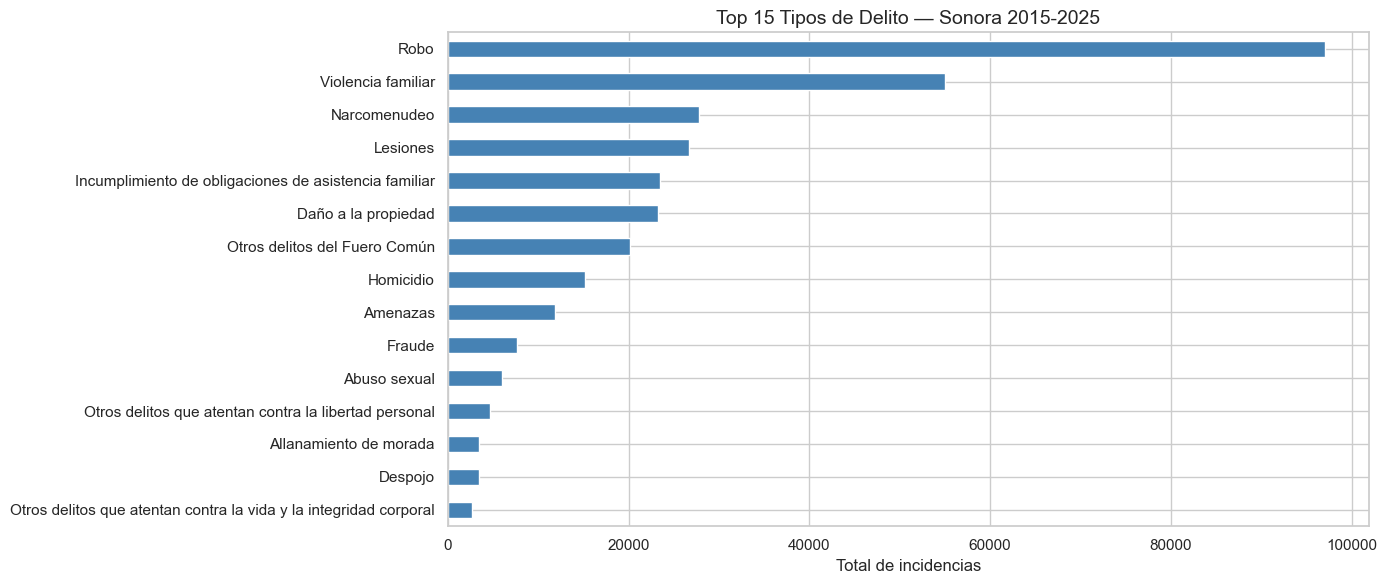

In [6]:
# Filtrar solo filas con datos
df_activo = df[~filas_cero].copy()

# Total de delitos por tipo
total_por_tipo = (
    df_activo.groupby("Tipo de delito")[meses]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

print("Top 15 tipos de delito (total acumulado 2015-2025):")
print(total_por_tipo.head(15))

# Gráfica
fig, ax = plt.subplots(figsize=(14, 6))
total_por_tipo.head(15).plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Top 15 Tipos de Delito — Sonora 2015-2025", fontsize=14)
ax.set_xlabel("Total de incidencias")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 7. Evolucion anual del crimen violento

Analizamos como han cambiado con el tiempo los delitos de mayor
interes para el proyecto: Homicidio, Robo, Lesiones, Violencia
familiar, Secuestro y Extorsion.

Esta vista temporal nos ayuda a identificar tendencias, cambios
de nivel y posibles anomalias que debamos investigar.

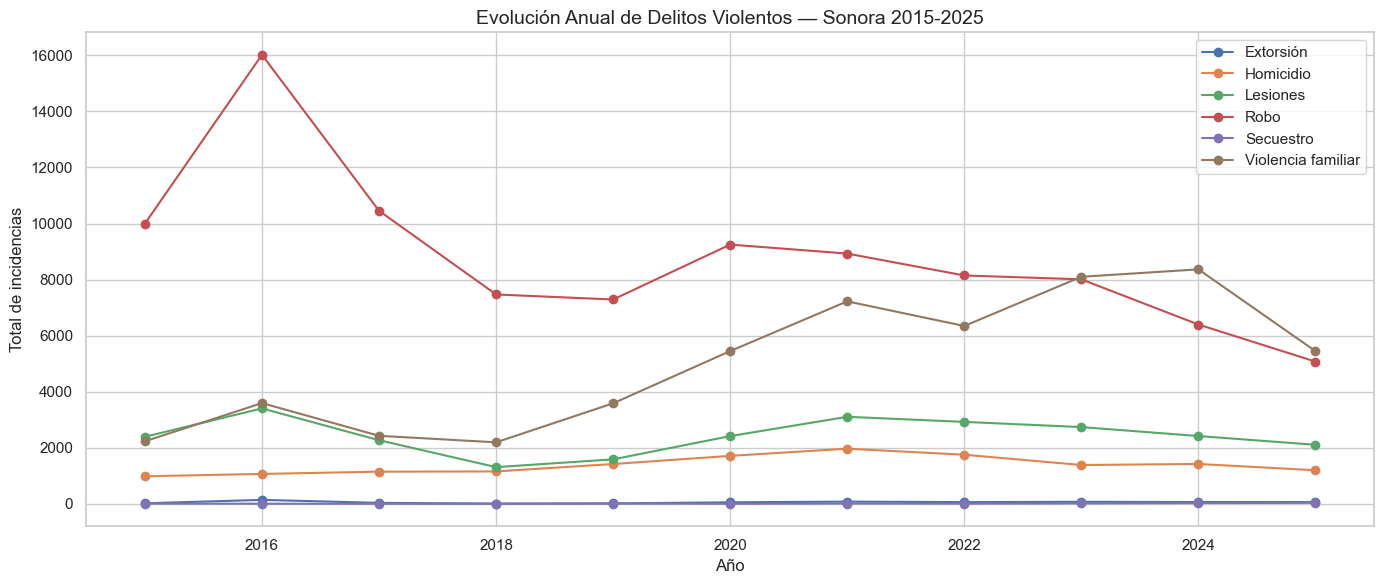

In [7]:
# Delitos de interés (crimen violento)
delitos_violentos = ["Homicidio", "Robo", "Lesiones", "Violencia familiar", "Secuestro", "Extorsión"]

# Total por año y tipo de delito
df_anual = (
    df_activo[df_activo["Tipo de delito"].isin(delitos_violentos)]
    .groupby(["Año", "Tipo de delito"])[meses]
    .sum()
    .sum(axis=1)
    .reset_index()
    .rename(columns={0: "total"})
)

# Gráfica
fig, ax = plt.subplots(figsize=(14, 6))
for delito, grupo in df_anual.groupby("Tipo de delito"):
    ax.plot(grupo["Año"], grupo["total"], marker="o", label=delito)

ax.set_title("Evolución Anual de Delitos Violentos — Sonora 2015-2025", fontsize=14)
ax.set_xlabel("Año")
ax.set_ylabel("Total de incidencias")
ax.legend()
plt.tight_layout()
plt.show()

### 8. Investigacion del pico de Robo en 2016

La grafica anterior muestra un pico notable de Robo en 2016,
casi el doble del resto de los años. Antes de asumir que es un
error de captura, investigamos que municipio lo genera y si los
valores estan distribuidos a lo largo del año (credibles)
o concentrados en un solo mes (sospechoso).

In [8]:
# Investigar el pico de Robo en 2016
robo_2016 = df[
    (df["Año"] == 2016) & 
    (df["Tipo de delito"] == "Robo")
].copy()

robo_2016["total"] = robo_2016[meses].sum(axis=1)
robo_2016 = robo_2016[robo_2016["total"] > 0].sort_values("total", ascending=False)

print("Top 10 registros de Robo en 2016:")
print(robo_2016[["Cve. Municipio", "Subtipo de delito", "Modalidad", "total"]].head(10))

# Comparar total de Robo por año
robo_anual = (
    df[df["Tipo de delito"] == "Robo"]
    .groupby("Año")[meses]
    .sum()
    .sum(axis=1)
)
print("\nTotal Robo por año:")
print(robo_anual)

Top 10 registros de Robo en 2016:
       Cve. Municipio           Subtipo de delito  \
10167           26030                 Otros robos   
10136           26030  Robo de vehículo automotor   
10168           26030                 Otros robos   
10133           26030      Robo a casa habitación   
8960            26018  Robo de vehículo automotor   
10134           26030      Robo a casa habitación   
8991            26018                 Otros robos   
12586           26055  Robo de vehículo automotor   
11410           26043  Robo de vehículo automotor   
8893            26017                 Otros robos   

                                     Modalidad  total  
10167                            Con violencia   3128  
10136  Robo de coche de 4 ruedas Sin violencia   1567  
10168                            Sin violencia   1294  
10133                            Con violencia   1116  
8960   Robo de coche de 4 ruedas Sin violencia    632  
10134                            Sin violencia

### 9. Verificacion del dato sospechoso

Revisamos el registro especifico que genera el pico y lo comparamos
con el mismo tipo de delito en otros años para el mismo municipio.
Esto nos dice si el dato es un outlier o simplemente un año
inusualmente alto pero real.

In [9]:
# Investigar municipio 26030 en 2016
print("Detalle del registro sospechoso (fila 10167):")
print(df.loc[10167, ["Año", "Cve. Municipio", "Subtipo de delito", "Modalidad"] + meses])

print("\n--- Comparar mismo subtipo/modalidad en otros años ---")
filtro = (
    (df["Cve. Municipio"] == 26030) &
    (df["Subtipo de delito"] == "Otros robos") &
    (df["Modalidad"] == "Con violencia")
)
comparacion = df[filtro][["Año"] + meses].copy()
comparacion["total"] = comparacion[meses].sum(axis=1)
print(comparacion[["Año", "total"]].sort_values("Año"))

Detalle del registro sospechoso (fila 10167):
Año                           2016
Cve. Municipio               26030
Subtipo de delito      Otros robos
Modalidad            Con violencia
Enero                          265
Febrero                        345
Marzo                          398
Abril                          399
Mayo                           356
Junio                          436
Julio                          377
Agosto                         102
Septiembre                     104
Octubre                         67
Noviembre                      110
Diciembre                      169
Name: 10167, dtype: object

--- Comparar mismo subtipo/modalidad en otros años ---
        Año  total
2915   2015    892
10167  2016   3128
17419  2017   1814
24671  2018    611
31923  2019    533
39175  2020   1139
46427  2021   1183
53679  2022   1013
60931  2023    949
68183  2024    501
75435  2025    356


### 10. Concentracion geografica del crimen

No todos los municipios contribuyen igual. Calculamos el total de
incidencias por municipio en todo el periodo y graficamos los 10
con mas delitos.

Esta informacion es critica para el modelo: si el crimen esta muy
concentrado en pocos municipios, el modelo necesita capturar esa
heterogeneidad geografica.

Top 10 municipios — concentración del crimen:
  Cajeme                     134,438  (39.2%)
  Hermosillo                  64,176  (18.7%)
  Nogales                     21,317  (6.2%)
  Guaymas                     20,966  (6.1%)
  Empalme                     15,980  (4.7%)
  Caborca                     13,991  (4.1%)
  Agua Prieta                 13,213  (3.9%)
  Alamos                       9,600  (2.8%)
  Navojoa                      6,036  (1.8%)
  San Luis Río Colorado        5,058  (1.5%)


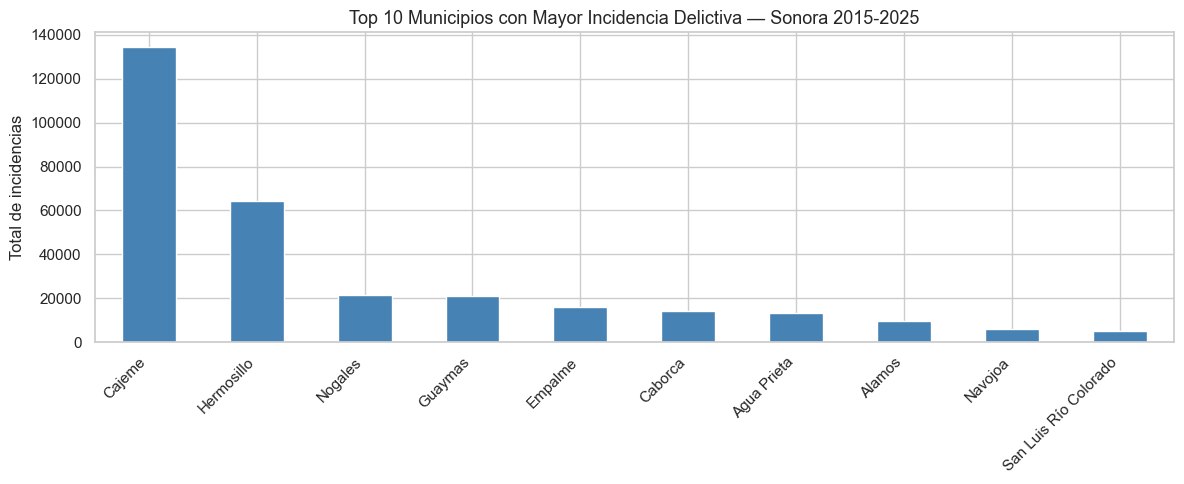

In [11]:
# Diccionario de municipios principales
nombres_municipios = {
    26030: "Cajeme",
    26018: "Hermosillo",
    26055: "Nogales",
    26043: "Guaymas",
    26042: "Empalme",  
    26029: "Caborca",
    26017: "Agua Prieta",
    26002: "Alamos",
    26033: "Navojoa",
    26048: "San Luis Río Colorado"
}

top_municipios_named = top_municipios.copy()
top_municipios_named.index = [nombres_municipios.get(i, str(i)) for i in top_municipios_named.index]

# Calcular % del total
total_general = df_activo["total"].sum()
print("Top 10 municipios — concentración del crimen:")
for mun, val in top_municipios_named.items():
    print(f"  {mun:<25} {val:>8,}  ({val/total_general*100:.1f}%)")

# Gráfica
fig, ax = plt.subplots(figsize=(12, 5))
top_municipios_named.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Top 10 Municipios con Mayor Incidencia Delictiva — Sonora 2015-2025", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Total de incidencias")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 11. Estacionalidad mensual

Analizamos si existen patrones estacionales en el numero de delitos.
Si ciertos meses tienen consistentemente mas incidencias, eso es
una señal util que el modelo puede aprender.

Comparamos la estacionalidad del total de delitos contra
la del crimen violento especificamente.

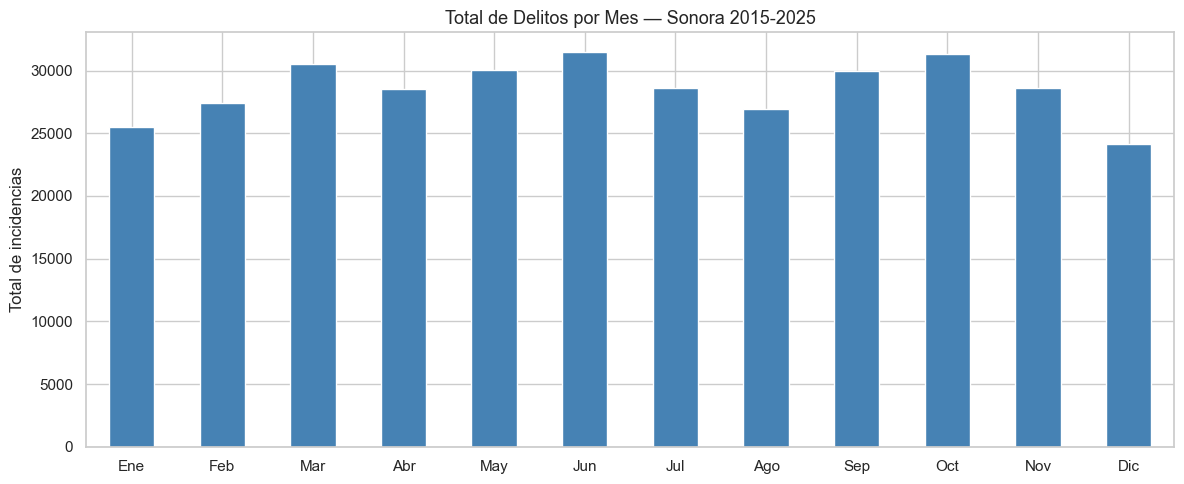


Estacionalidad solo crimen violento (Homicidio + Robo con violencia):
Ene    8149
Feb    8133
Mar    8742
Abr    8155
May    8775
Jun    8900
Jul    8655
Ago    7306
Sep    7766
Oct    8054
Nov    7630
Dic    6779
dtype: int64


In [12]:
# Estacionalidad mensual — ¿hay meses más violentos?
nombres_meses = ["Ene","Feb","Mar","Abr","May","Jun",
                 "Jul","Ago","Sep","Oct","Nov","Dic"]

estacionalidad = df_activo[meses].sum()
estacionalidad.index = nombres_meses

fig, ax = plt.subplots(figsize=(12, 5))
estacionalidad.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Total de Delitos por Mes — Sonora 2015-2025", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Total de incidencias")
ax.set_xticklabels(nombres_meses, rotation=0)
plt.tight_layout()
plt.show()

# Solo para crimen violento
print("\nEstacionalidad solo crimen violento (Homicidio + Robo con violencia):")
violento = df_activo[
    (df_activo["Tipo de delito"].isin(["Homicidio", "Robo"])) &
    (df_activo["Modalidad"].str.contains("violencia|violento", case=False, na=False))
]
estac_violento = violento[meses].sum()
estac_violento.index = nombres_meses
print(estac_violento)

Visualizamos ambas estacionalidades en paralelo para comparar
si el patron del crimen violento difiere del patron general.

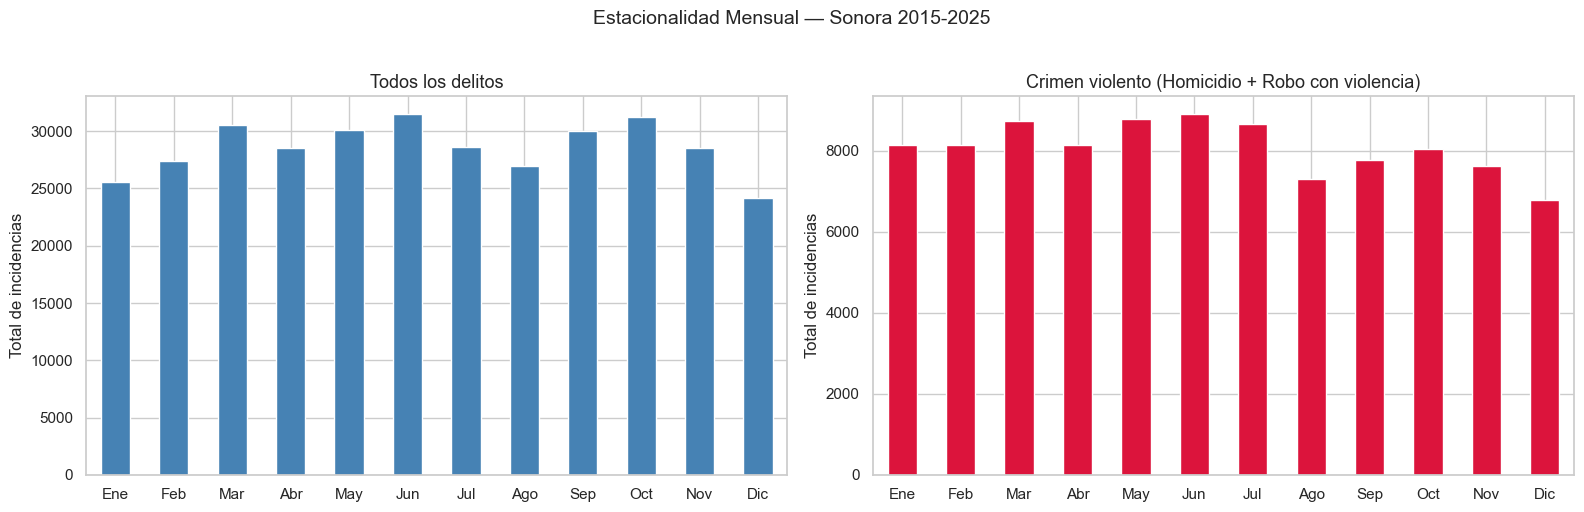

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total general
estacionalidad.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Todos los delitos", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_xticklabels(nombres_meses, rotation=0)
axes[0].set_ylabel("Total de incidencias")

# Crimen violento
estac_violento.plot(kind="bar", ax=axes[1], color="crimson")
axes[1].set_title("Crimen violento (Homicidio + Robo con violencia)", fontsize=13)
axes[1].set_xlabel("")
axes[1].set_xticklabels(nombres_meses, rotation=0)
axes[1].set_ylabel("Total de incidencias")

plt.suptitle("Estacionalidad Mensual — Sonora 2015-2025", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 12. Distribucion del target

Analizamos la distribucion del conteo total por registro (filas activas).
Esto nos anticipa si el target es simetrico, tiene cola larga o tiene
muchos ceros — informacion fundamental para elegir el tipo de modelo.

Mostramos el histograma completo y un zoom sin los outliers extremos
(percentil 95) para ver mejor la masa de la distribucion.

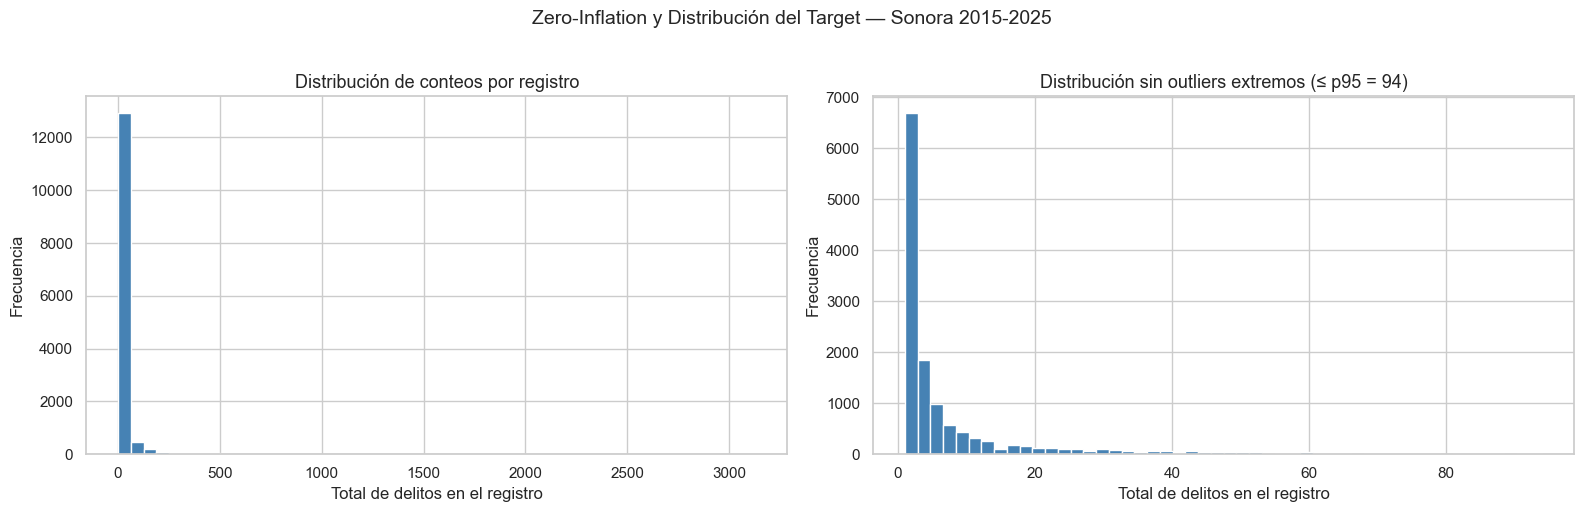


Estadísticas descriptivas del total por registro:
count    13902.000000
mean        24.681916
std        115.020879
min          1.000000
50%          3.000000
75%         10.000000
90%         42.000000
95%         94.000000
99%        429.990000
max       3128.000000
Name: total, dtype: float64


In [14]:
# Distribución del total por registro (solo filas activas)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma general
axes[0].hist(df_activo["total"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribución de conteos por registro", fontsize=13)
axes[0].set_xlabel("Total de delitos en el registro")
axes[0].set_ylabel("Frecuencia")

# Zoom — sin outliers extremos (percentil 95)
p95 = df_activo["total"].quantile(0.95)
axes[1].hist(df_activo[df_activo["total"] <= p95]["total"], bins=50, color="steelblue", edgecolor="white")
axes[1].set_title(f"Distribución sin outliers extremos (≤ p95 = {p95:.0f})", fontsize=13)
axes[1].set_xlabel("Total de delitos en el registro")
axes[1].set_ylabel("Frecuencia")

plt.suptitle("Zero-Inflation y Distribución del Target — Sonora 2015-2025", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nEstadísticas descriptivas del total por registro:")
print(df_activo["total"].describe(percentiles=[.5, .75, .90, .95, .99]))

### 13. Resumen ejecutivo

Consolidamos los hallazgos mas importantes del EDA en un bloque
de texto estructurado para facilitar la comunicacion con el equipo
y el Subject Matter Expert.

In [16]:
# Resumen ejecutivo del EDA
print("=" * 60)
print("RESUMEN EDA — INCIDENCIA DELICTIVA SONORA 2015-2025")
print("=" * 60)

print(f"""
ESTRUCTURA
  - {df.shape[0]:,} registros totales | 11 años | 18 columnas
  - {df['Cve. Municipio'].nunique()} municipios | {df['Tipo de delito'].nunique()} tipos de delito
  - Sin valores nulos en ningún archivo

SPARSITY
  - 82.6% de filas con todos los meses en cero
  - Solo 13,902 registros activos (17.4%)

CONCENTRACIÓN GEOGRÁFICA
  - Cajeme (26030):    {134438/total_general*100:.1f}% del total de delitos
  - Hermosillo (26018): {64176/total_general*100:.1f}% del total de delitos
  - Top 2 municipios concentran más del 60% del crimen estatal

TOP DELITOS (2015-2025)
  1. Robo            97,044
  2. Violencia familiar 54,971
  3. Narcomenudeo    27,765
  4. Lesiones        26,679

ESTACIONALIDAD
  - Diciembre es el mes más bajo consistentemente
  - Junio-Octubre son los meses más altos
  - Patrón suave, no dramático

DISTRIBUCIÓN DEL TARGET
  - Mediana: 3 | Media: 24.7 | Máx: 3,128
  - Distribución con cola larga extrema (zero-inflated)
  - El 95% de registros activos tienen ≤ 94 delitos

ANOMALÍAS DETECTADAS
  - Pico de Robo en 2016 en Cajeme — dato real, no error
  - 2025 con valores bajos — año incompleto
""")

RESUMEN EDA — INCIDENCIA DELICTIVA SONORA 2015-2025

ESTRUCTURA
  - 79,772 registros totales | 11 años | 18 columnas
  - 74 municipios | 40 tipos de delito
  - Sin valores nulos en ningún archivo

SPARSITY
  - 82.6% de filas con todos los meses en cero
  - Solo 13,902 registros activos (17.4%)

CONCENTRACIÓN GEOGRÁFICA
  - Cajeme (26030):    39.2% del total de delitos
  - Hermosillo (26018): 18.7% del total de delitos
  - Top 2 municipios concentran más del 60% del crimen estatal

TOP DELITOS (2015-2025)
  1. Robo            97,044
  2. Violencia familiar 54,971
  3. Narcomenudeo    27,765
  4. Lesiones        26,679

ESTACIONALIDAD
  - Diciembre es el mes más bajo consistentemente
  - Junio-Octubre son los meses más altos
  - Patrón suave, no dramático

DISTRIBUCIÓN DEL TARGET
  - Mediana: 3 | Media: 24.7 | Máx: 3,128
  - Distribución con cola larga extrema (zero-inflated)
  - El 95% de registros activos tienen ≤ 94 delitos

ANOMALÍAS DETECTADAS
  - Pico de Robo en 2016 en Cajeme — da